# Algorithme "diviser pour régner"
Exercices sur les tableaux
## Recherche du couple (minimum, maximum) dans un tableau

### Question 1

In [1]:
def min_et_max(T, a, b):
    if len(T[a:b]) == 1:
        return T[a], T[a]
    elif len(T[a:b]) == 2:
        if T[a] < T[b-1]:
            return T[a], T[b-1]
        else:
            return T[b-1], T[a]
    else:
        i = 0
        c = (a+b)//2
        T1 = min_et_max(T, a, c)
        T2 = min_et_max(T, c, b)

        if T1[0] < T2[0]:
            min = T1[0]
        else:
            min = T2[0]
        if T1[1] > T2[1]:
            max = T1[1]
        else:
            max = T2[1]
    return min, max

In [2]:
a=[5,3,8,1]
min_et_max(a, 0, len(a))

(1, 8)

### Question 2.a
Il faut 18 comparaisons. On stocke T[0] dans mini et dans maxi, puis on compare chacun des 9 autres
éléments à min et à max.

### Question 2.b

L’appel de min_et_max sur T[0:10[ entraine les appels récursifs suivants:  
```
T[0:10[: 2 comparaisons lors de la phase combiner
    • T[0:5[           2 comparaisons lors de la phase combiner
        - T[0:2[       1 comparaison
        - T[2,5[       2 comparaisons lors de la phase combiner
            * T[2,3[
            * T[3,5[   1 comparaison
    • T[5:10[          2 comparaisons lors de la phase combiner
        - T[5:7[       1 comparaison
        - T[7:10[      2 comparaisons lors de la phase combiner
            * T[7:8[
            * T[8:10[  1 comparaison
```

Soit un total de 14 comparaisons.

### Question 2.c
Avec 20 nombres, de manière classique, il faut 38 comparaisons. Avec l’algorithme « diviser pour régner,
il en faut 14 + 14 + 2 = 30. Avec 40 nombres, l’algorithme naïf effectue 78 comparaisons et l’algorithme
diviser pour régner 62.

## Exercice 2

### Partie A


### Question 1
Solution avec slicing(`[:]`) :

In [3]:
def copie_partielle(tab, imax, jmax):
    return tab[imax:jmax+1]

2nde solution équivalente à la précédent mais sans slicing :

In [4]:
def copie_partielle(tab, imax, jmax):
    n = jmax + 1 - imax
    copie_tab = [0] * n
    for i in range(n):
        copie_tab[i] = tab[imax + i]
    return copie_tab

### Question 2

In [5]:
def tranche(tab):
    """
    Recherche la portion de tableau ayant la somme des éléments maximum
    """
    n = len(tab)
    smax = tab[0]
    imax = jmax = 0
    for i in range(n):
        s = 0
        for j in range(i, n):
            s += tab[j]
            if s > smax:
                smax = s
                imax = i
                jmax = j
    return copie_partielle(tab, imax, jmax)
    # renvoie une copie du sous-tableau tab[imax:jmax+1[

### Question 3

In [6]:
tranche([3, -4, 2, -1, 5, -3]) 

[2, -1, 5]

### Question 4
Les instructions internes aux deux boucles `for` imbriquées prennent un temps
constant ($O(n)$). Elles seront exécutées un nombre de fois égal à $n + (n – 1) + … + 2 + 1 = n^2/2$, soit $O(n^2)$. 

==> La complexité de tranche est quadratique : $O(n²)$

La fonction tranche renvoie une tranche (slice) du tableau tab de somme maximale.

### Question 5
Il suffit de modifier la ligne `if s > smax:`  
par : `if s > smax or (s == smax and j - i < jmax - imax):`

In [7]:
def tranche(tab):
    """
    Recherche la portion de tableau ayant la somme des éléments maximum
    """
    n = len(tab)
    smax = tab[0]
    imax = jmax = 0
    for i in range(n):
        s = 0
        for j in range(i, n):
            s += tab[j]
            if s > smax or (s == smax and j - i < jmax - imax):
                smax = s
                imax = i
                jmax = j
    return copie_partielle(tab, imax, jmax)
    # renvoie une copie du sous-tableau tab[imax:jmax+1[

In [8]:
tranche([3, -4, 2, -1, 5, -3])

[2, -1, 5]

### Partie B - *difficile*
### Question 1

*Tout au long de l'algorithme, `tab` représente le tableau donné en paramètre au départ.
La sélection d'une portion de tableau se fait en faisant varier les indices de départ (`a`) et de fin (`b`).*

- Si le tableau est de longueur 1, on renvoie `[tab[0]]`.  
- Si le tableau est de longueur 2, on teste les trois tranches `[tab[0]], [tab[1]], tab[0:2]`.  
- Sinon, on coupe le tableau en deux tableaux de même taille tab1 et tab2, on détermine récursivement la
tranche de somme maximale minimum sur `tab1` et `tab2`. On renvoie ces tranches ainsi que la valeur de
leurs sommes. On construit ensuite la tranche de somme maximale parmi les tranches à cheval sur les
deux sous-tableaux en concaténant la tranche de somme maximale du tableau `tab1` de type `tab1[i:]` et la
tranche de somme maximale du tableau `tab2` de type `tab2[:j]`.

Voici une représentation de l'algorithme :
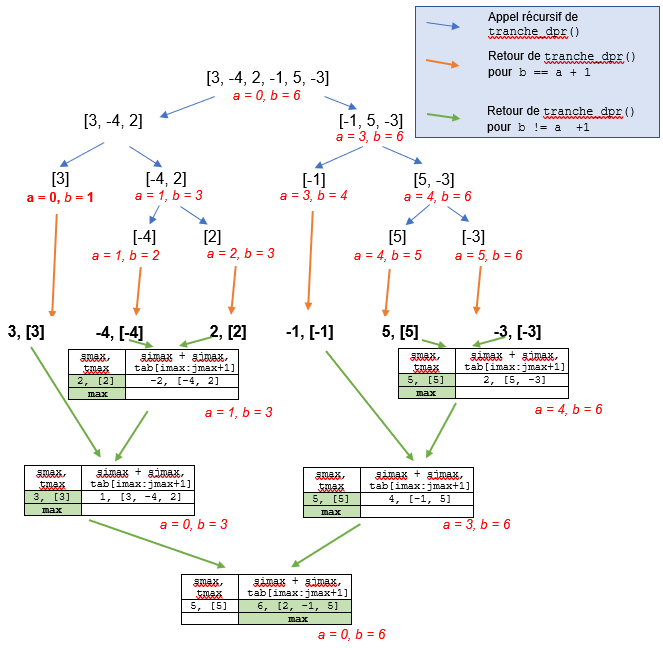

In [9]:
def tranche_dpr(tab):
    def tranche_dpr_(tab, a, b):
        #############################################################################
        #
        # 1. Recherche de la valeur max du tab retournée sous la forme : (valeur, [valeur])
        #
        #############################################################################

        if b == a + 1:                 # Si le tableau est de longueur 1
            return tab[a], tab[a:b]    #
        else:                          # Sinon on coupe le tableau par le milieu
            c = (a + b)//2
            # récursivité sur la première moitié du tableau
            s1, t1 = tranche_dpr_(tab, a, c)
            # récursivité sur la seconde moitié du tableau
            s2, t2 = tranche_dpr_(tab, c, b)
            # Sélection du maximum entre les deux parties
            smax, tmax = max((s1, t1), (s2, t2))

        #############################################################################
        #
        # 2. Recherche de la somme maximum dans chaque demi tableau en partant du milieu (c)
        #
        #############################################################################

            # On considére la dernière valeur du demi tableau comme la somme maximum
            simax = tab[c - 1]
            imax = c - 1            # imax est l'indice de départ de la tranche recherchée
            s = 0                   # somme des différents éléments du demi tableau

            for i in range(c-1, a-1, -1):   # Pour i allant de milieu à la première position
                                            # de la portion de tableau considérée
                                            # On calcule la somme de toutes les valeurs
                s += tab[i]
                if s > simax:               # Si la nouvelle somme > la somme maximum mémorisée
                    simax = s               # Alors elle devient la nouvelle somme maximum
                    imax = i                # mémorisation de l'indice de départ de la tranche recherchée

            sjmax = tab[c]          # Même principe pour le second demi tableau
            jmax = c
            s = 0

            for j in range(c, b):   # Pour j allant de milieu à la dernière position
                s += tab[j]
                if s > sjmax:
                    sjmax = s
                    jmax = j

        #############################################################################
        #
        # 3. Sélection du maximum entre les résultats de 1. et 2.
        #
        #############################################################################

            # on renvoie l'élément le plus grand entre l'élément maximum et la somme
            return max((smax, tmax), (simax + sjmax, tab[imax:jmax+1]))

    return tranche_dpr_(tab, 0, len(tab))

In [10]:
tranche_dpr([3, -4, 2, -1, 5, -3])

(6, [2, -1, 5])

### Execution avec PythonTutor
[PythonTutor](http://pythontutor.com/iframe-embed.html#code=def%20tranche_dpr_%28tab%2C%20a%2C%20b%29%3A%0A%20%20%20%20%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%0A%20%20%20%20%23%20%0A%20%20%20%20%23%201.%20Recherche%20de%20la%20valeur%20max%20du%20tab%20retourn%C3%A9e%20sous%20la%20forme%20%3A%20%28valeur%2C%20%5Bvaleur%5D%29%0A%20%20%20%20%23%0A%20%20%20%20%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%0A%20%20%20%20%0A%20%20%20%20if%20b%20%3D%3D%20a%20%2B%201%3A%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%23%20Si%20le%20tableau%20est%20de%20longueur%201%0A%20%20%20%20%20%20%20%20return%20tab%5Ba%5D%2C%20tab%5Ba%3Ab%5D%20%20%20%20%23%0A%20%20%20%20else%3A%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%23%20Sinon%20on%20coupe%20le%20tableau%20par%20le%20milieu%0A%20%20%20%20%20%20%20%20c%20%3D%20%28a%20%2B%20b%29//2%0A%20%20%20%20%20%20%20%20%23%20r%C3%A9cursivit%C3%A9%20sur%20la%20premi%C3%A8re%20moiti%C3%A9%20du%20tableau%0A%20%20%20%20%20%20%20%20s1%2C%20t1%20%3D%20tranche_dpr_%28tab%2C%20a%2C%20c%29%0A%20%20%20%20%20%20%20%20%23%20r%C3%A9cursivit%C3%A9%20sur%20la%20seconde%20moiti%C3%A9%20du%20tableau%0A%20%20%20%20%20%20%20%20s2%2C%20t2%20%3D%20tranche_dpr_%28tab%2C%20c%2C%20b%29%0A%20%20%20%20%20%20%20%20%23%20S%C3%A9lection%20du%20maximum%20entre%20les%20deux%20parties%0A%20%20%20%20%20%20%20%20smax%2C%20tmax%20%3D%20max%28%28s1%2C%20t1%29%2C%20%28s2%2C%20t2%29%29%0A%20%20%20%20%20%20%20%20%0A%20%20%20%20%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%0A%20%20%20%20%23%20%0A%20%20%20%20%23%202.%20Recherche%20de%20la%20somme%20maximum%20dans%20chaque%20demi%20tableau%20en%20partant%20du%20milieu%20%28c%29%0A%20%20%20%20%23%0A%20%20%20%20%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%0A%20%20%20%20%20%20%20%20%0A%20%20%20%20%20%20%20%20%23%20On%20consid%C3%A9re%20la%20derni%C3%A8re%20valeur%20du%20demi%20tableau%20comme%20la%20somme%20maximum%0A%20%20%20%20%20%20%20%20simax%20%3D%20tab%5Bc%20-%201%5D%0A%20%20%20%20%20%20%20%20imax%20%3D%20c%20-%201%20%20%20%20%20%20%20%20%20%20%20%20%23%20imax%20est%20l%27indice%20de%20d%C3%A9part%20de%20la%20tranche%20recherch%C3%A9e%0A%20%20%20%20%20%20%20%20s%20%3D%200%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%23%20somme%20des%20diff%C3%A9rents%20%C3%A9l%C3%A9ments%20du%20demi%20tableau%0A%0A%20%20%20%20%20%20%20%20for%20i%20in%20range%28c-1%2C%20a-1%2C%20-1%29%3A%20%20%20%23%20Pour%20i%20allant%20de%20milieu%20%C3%A0%20la%20premi%C3%A8re%20position%0A%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%23%20de%20la%20portion%20de%20tableau%20consid%C3%A9r%C3%A9e%0A%20%20%20%20%20%20%20%20%20%20%20%20%23%20On%20calcule%20la%20somme%20de%20toutes%20les%20valeurs%0A%20%20%20%20%20%20%20%20%20%20%20%20s%20%2B%3D%20tab%5Bi%5D%0A%20%20%20%20%20%20%20%20%20%20%20%20if%20s%20%3E%20simax%3A%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%23%20Si%20la%20nouvelle%20somme%20%3E%20la%20somme%20maximum%20m%C3%A9moris%C3%A9e%0A%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20simax%20%3D%20s%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%23%20Alors%20elle%20devient%20la%20nouvelle%20somme%20maximum%0A%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20imax%20%3D%20i%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%23%20m%C3%A9morisation%20de%20l%27indice%20de%20d%C3%A9part%20de%20la%20tranche%20recherch%C3%A9e%0A%0A%20%20%20%20%20%20%20%20sjmax%20%3D%20tab%5Bc%5D%20%20%20%20%20%20%20%20%20%20%23%20M%C3%AAme%20principe%20pour%20le%20second%20demi%20tableau%0A%20%20%20%20%20%20%20%20jmax%20%3D%20c%0A%20%20%20%20%20%20%20%20s%20%3D%200%0A%0A%20%20%20%20%20%20%20%20for%20j%20in%20range%28c%2C%20b%29%3A%20%20%20%23%20Pour%20j%20allant%20de%20milieu%20%C3%A0%20la%20derni%C3%A8re%20position%0A%20%20%20%20%20%20%20%20%20%20%20%20s%20%2B%3D%20tab%5Bj%5D%0A%20%20%20%20%20%20%20%20%20%20%20%20if%20s%20%3E%20sjmax%3A%0A%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20sjmax%20%3D%20s%0A%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20jmax%20%3D%20j%0A%20%20%20%20%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%0A%20%20%20%20%23%20%0A%20%20%20%20%23%203.%20S%C3%A9lection%20du%20maximum%20entre%20les%20r%C3%A9sultats%20de%201.%20et%202.%0A%20%20%20%20%23%0A%20%20%20%20%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%23%0A%0A%20%20%20%20%20%20%20%20%23%20on%20renvoie%20l%27%C3%A9l%C3%A9ment%20le%20plus%20grand%20entre%20l%27%C3%A9l%C3%A9ment%20maximum%20et%20la%20somme%0A%20%20%20%20%20%20%20%20return%20max%28%28smax%2C%20tmax%29%2C%20%28simax%20%2B%20sjmax%2C%20tab%5Bimax%3Ajmax%2B1%5D%29%29%0A%0A%0Adef%20tranche_dpr%28tab%29%3A%0A%20%20%20%20return%20tranche_dpr_%28tab%2C%200%2C%20len%28tab%29%29%0A%0Atranche_dpr%28%5B3%2C%20-4%2C%202%2C%20-1%2C%205%2C%20-3%5D%29%0A&origin=opt-frontend.js&cumulative=false&heapPrimitives=false&textReferences=false&curInstr=0&&verticalStack=false&py=3&rawInputLstJSON=%5B%5D&codeDivWidth=50%25&codeDivHeight=100%25)

In [13]:
%%tutor -h 900 --curInstr 70
def tranche_dpr_(tab, a, b):
    #############################################################################
    # 
    # 1. Recherche de la valeur max du tab retournée sous la forme : (valeur, [valeur])
    #
    #############################################################################
    
    if b == a + 1:                 # Si le tableau est de longueur 1
        return tab[a], tab[a:b]    #
    else:                          # Sinon on coupe le tableau par le milieu
        c = (a + b)//2
        # récursivité sur la première moitié du tableau
        s1, t1 = tranche_dpr_(tab, a, c)
        # récursivité sur la seconde moitié du tableau
        s2, t2 = tranche_dpr_(tab, c, b)
        # Sélection du maximum entre les deux parties
        smax, tmax = max((s1, t1), (s2, t2))
        
    #############################################################################
    # 
    # 2. Recherche de la somme maximum dans chaque demi tableau en partant du milieu (c)
    #
    #############################################################################
        
        # On considére la dernière valeur du demi tableau comme la somme maximum
        simax = tab[c - 1]
        imax = c - 1            # imax est l'indice de départ de la tranche recherchée
        s = 0                   # somme des différents éléments du demi tableau

        for i in range(c-1, a-1, -1):   # Pour i allant de milieu à la première position
                                        # de la portion de tableau considérée
            # On calcule la somme de toutes les valeurs
            s += tab[i]
            if s > simax:               # Si la nouvelle somme > la somme maximum mémorisée
                simax = s               # Alors elle devient la nouvelle somme maximum
                imax = i                # mémorisation de l'indice de départ de la tranche recherchée

        sjmax = tab[c]          # Même principe pour le second demi tableau
        jmax = c
        s = 0

        for j in range(c, b):   # Pour j allant de milieu à la dernière position
            s += tab[j]
            if s > sjmax:
                sjmax = s
                jmax = j
    #############################################################################
    # 
    # 3. Sélection du maximum entre les résultats de 1. et 2.
    #
    #############################################################################

        # on renvoie l'élément le plus grand entre l'élément maximum et la somme
        return max((smax, tmax), (simax + sjmax, tab[imax:jmax+1]))


def tranche_dpr(tab):
    return tranche_dpr_(tab, 0, len(tab))

tranche_dpr([3, -4, 2, -1, 5, -3])